In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch

print("setup works")

Matplotlib is building the font cache; this may take a moment.


setup works


True
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
Number of classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
{'A': 3000, 'B': 3000, 'C': 3000, 'D': 3000, 'E': 3000, 'F': 3000, 'G': 3000, 'H': 3000, 'I': 3000, 'J': 3000, 'K': 3000, 'L': 3000, 'M': 3000, 'N': 3000, 'O': 3000, 'P': 3000, 'Q': 3000, 'R': 3000, 'S': 3000, 'T': 3000, 'U': 3000, 'V': 3000, 'W': 3000, 'X': 3000, 'Y': 3000, 'Z': 3000, 'del': 3000, 'nothing': 3000, 'space': 3000}


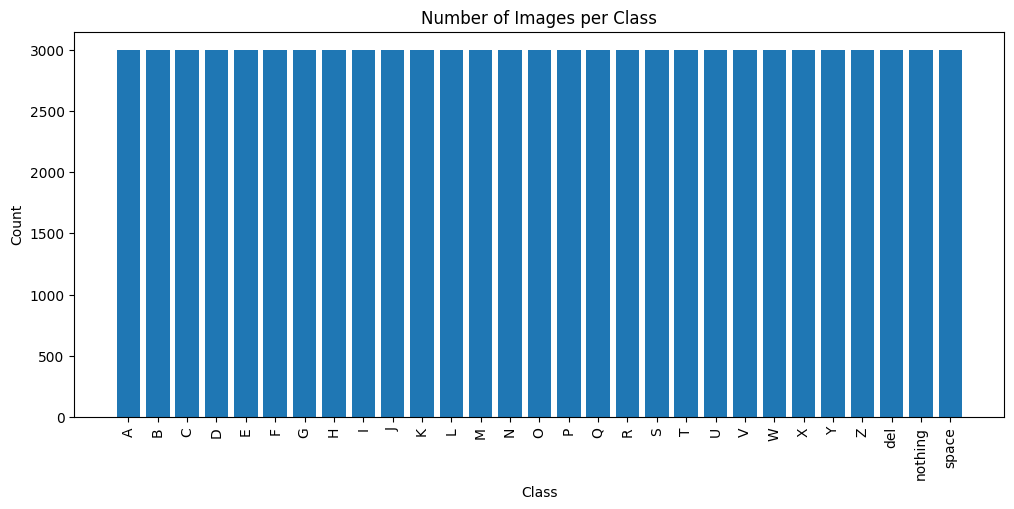

In [4]:
import os

data_dir = "data"
print(os.path.exists(data_dir))
print(sorted(os.listdir(data_dir))[:10])

classes = sorted([c for c in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, c))])
print("Number of classes:", len(classes))
print(classes)

class_counts = {}

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    if os.path.isdir(class_path):
        class_counts[cls] = len(os.listdir(class_path))

print(class_counts)

plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

img_size = 64
max_per_class = 800  

X = []
y = []

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    images = os.listdir(class_path)
    
    for img_name in images[:max_per_class]:
        img_path = os.path.join(class_path, img_name)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        img = cv2.resize(img, (img_size, img_size))
        
        X.append(img)
        y.append(cls)

X = np.array(X)
y = np.array(y)

X = X / 255.0

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (18560, 64, 64, 3)
Test: (4640, 64, 64, 3)


In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    max_iter=30,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train_flat, y_train)
y_pred_mlp = mlp.predict(X_test_flat)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
print("MLP Accuracy:", mlp_acc)

/Users/vaishantreddy/asl-project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Accuracy: 0.7946120689655173


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score
import numpy as np

# convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=len(le.classes_)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cnn_acc = accuracy_score(all_labels, all_preds)
print("CNN Accuracy:", cnn_acc)

Epoch 1/5, Loss: 2.3447
Epoch 2/5, Loss: 0.9579
Epoch 3/5, Loss: 0.5009
Epoch 4/5, Loss: 0.3120
Epoch 5/5, Loss: 0.2109
CNN Accuracy: 0.9310344827586207


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_flat, y_train)

y_pred_lr = logreg.predict(X_test_flat)
lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)

KeyboardInterrupt: 

In [12]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train_flat, y_train)

y_pred_svm = svm.predict(X_test_flat)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.8454741379310344


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Logistic Regression Accuracy:", lr_acc)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=le.classes_)
disp_lr.plot(xticks_rotation=90)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


print("SVM Accuracy:", svm_acc)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=le.classes_)
disp_svm.plot(xticks_rotation=90)
plt.title("SVM Confusion Matrix")
plt.show()


print("MLP Accuracy:", mlp_acc)
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(cm_mlp, display_labels=le.classes_)
disp_mlp.plot(xticks_rotation=90)
plt.title("MLP Confusion Matrix")
plt.show()


print("CNN Accuracy:", cnn_acc)
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm_cnn = confusion_matrix(all_labels, all_preds)
disp_cnn = ConfusionMatrixDisplay(cm_cnn, display_labels=le.classes_)
disp_cnn.plot(xticks_rotation=90)
plt.title("CNN Confusion Matrix")
plt.show()

In [14]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["MLP", "CNN"],
    "Accuracy": [mlp_acc, cnn_acc]
})

print(results)

  Model  Accuracy
0   MLP  0.794612
1   CNN  0.931034
